# Рубль или нефть? И что изменил плавающий курс

Первый ноутбук закончился на том, что рубль — ближайший попутчик тенге,
но объясняет всего десятую часть его дневных движений. Оставался очевидный
вопрос: а нефть? И столь же очевидное ограничение: выборка с 2021 года
не видела ни одной девальвации, то есть ровно тех событий, которые
и сформировали отношение казахстанцев к курсу.

Здесь оба пробела закрыты:

- курсы Нацбанка с **2005 года** — из Excel-выгрузки, а не из XML-эндпоинта;
- дневная цена **Brent** из открытой базы FRED.

Выборка теперь захватывает девальвацию февраля 2009, девальвацию февраля 2014
и переход к свободному плаванию 20 августа 2015 года.

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import analysis as A
from src import clean, config, features

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (11, 4.2), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
FLOAT = pd.Timestamp(config.FLOAT_DATE)

## 1. Почему источников два

XML-эндпоинт Нацбанка отдаёт все 48 котируемых валют, но только с мая 2021 года.
Excel-выгрузка с того же сайта тянется с 1999-го, зато валюты приходится
перечислять по внутренним id формы. Для длинного ряда взята вторая.

Одна деталь важна именно на длинном горизонте: **кратность котировки менялась**.
Узбекский сум в 2013 году публиковался за 1 единицу, а к 2016-му — уже за 100.
Поэтому делить на кратность нужно построчно.

In [2]:
wide = clean.load_clean_long()
brent = clean.load_brent()
print("курсы:", wide.shape, wide.index.min().date(), "->", wide.index.max().date())
wide[["USD", "RUB", "CNY", "UZS"]].head(3)

Прочитал нефть: 5643 дней, 2004-06-01 .. 2026-09-09
курсы: (5352, 15) 2005-01-01 -> 2026-09-11


,USD,RUB,CNY,UZS
date,,,,
2005-01-01,130.0,4.68,15.71,0.12
2005-01-06,130.0,4.69,15.71,0.12
2005-01-07,130.0,4.66,15.71,0.12


In [3]:
codes = [c for c in wide.columns if c != "USD"]
prices = features.attach_brent(
    features.to_trading_date(features.to_usd_base(wide, currencies=codes)), brent
)
rets = features.log_returns(prices)
labels = features.regime(rets.index)
labels.value_counts()

  нефть покрывает 96.6% торговых дней
  обнуляю доходность через разрывы календаря: ['2010-03-25', '2011-03-24', '2012-03-26', '2013-03-26', '2014-01-06', '2014-03-26', '2015-03-26', '2016-03-24', '2017-03-24', '2018-03-26', '2019-03-26', '2020-03-26', '2021-03-25', '2022-01-12', '2022-03-24', '2024-03-26', '2025-03-26', '2026-03-26']


плавающий курс      2721
управляемый курс    2630
Name: count, dtype: int64

## 2. Двадцать лет одной картинкой

Логарифмическая шкала нужна, чтобы движение со 130 до 190 было видно так же,
как движение с 300 до 450.

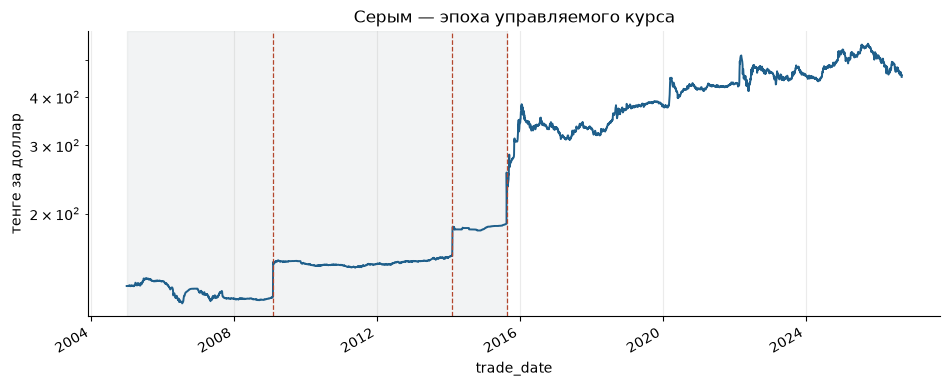

In [4]:
ax = prices["KZT"].plot(color="#1f5f8b", lw=1.4, logy=True)
ax.axvspan(prices.index[0], FLOAT, color="#9aa0a6", alpha=.12)
for day, label in config.DEVALUATIONS.items():
    ax.axvline(pd.Timestamp(day), color="#b3452c", lw=.9, ls="--")
ax.set_ylabel("тенге за доллар")
ax.set_title("Серым — эпоха управляемого курса")
plt.show()

Это не график валюты. Это график решений: три почти вертикальные ступеньки
и почти плоские участки между ними.

## 3. До 2015 года курс был не волатильным, а взрывным

Обычная мера риска — среднеквадратичное отклонение — в таком режиме
описывает не рынок, а два-три дня из тысячи.

In [5]:
regimes = A.regime_table(rets, labels, "KZT", ["RUB", "BRENT", "CNY", "EUR"])
regimes.round(3)

,corr RUB,corr BRENT,corr CNY,corr EUR,волатильность_год_%,дней_без_движения_%,наблюдений
плавающий курс,0.243,-0.069,0.060,0.087,14.881,0.295,2710.0
управляемый курс,0.017,0.004,0.006,0.007,7.038,13.687,2623.0


In [6]:
A.excluding_jumps_volatility(rets.loc[rets.index < FLOAT, "KZT"], n=3)

{'волатильность_год_%': 7.037917186765165,
 'без_3_скачков_%': 2.819872541887479,
 'скачки': {'2009-02-04': 16.3, '2014-02-12': 11.8, '2014-02-11': 5.2}}

Волатильность эпохи управляемого курса — 7,0% годовых. Убираем три дня —
остаётся 2,8%. И 13,7% дней курс не менялся вообще: ни на тиын.
После перехода к плаванию таких дней 0,3%.

## 4. Сколько стоят три дня

In [7]:
A.jump_contribution(rets["KZT"])

,доля_дней_%,вклад_%,доля_ослабления_%,даты
дней,,,,
1,0.018751,30.382143,24.267433,2015-08-20
3,0.056254,58.524825,46.746118,"2015-08-20, 2009-02-04, 2014-02-12"
5,0.093756,73.612902,58.797568,"2015-08-20, 2009-02-04, 2014-02-12, 2015-09-14..."
10,0.187512,101.995539,81.467916,"2015-08-20, 2009-02-04, 2014-02-12, 2015-09-14..."


Три дня из 5333 — это 0,06% выборки — дают 47% всего ослабления тенге
за двадцать лет. Десять дней дают 81%.

## 5. Теперь про нефть

Начинаем с самого прямого вопроса: коррелируют ли дневные изменения курса
с дневными изменениями Brent после перехода к плаванию?

In [8]:
post = rets[rets.index >= FLOAT]
pair = post[["KZT", "BRENT"]].dropna()
print(f"дневная корреляция тенге с нефтью: {pair['KZT'].corr(pair['BRENT']):+.3f} (n={len(pair)})")
print(f"для сравнения, с рублём:           {post[['KZT','RUB']].dropna().corr().iloc[0,1]:+.3f}")

дневная корреляция тенге с нефтью: -0.069 (n=2570)
для сравнения, с рублём:           +0.246


Почти ничего. Но прежде чем объявлять нефтяную версию несостоятельной,
стоит проверить две вещи: правильно ли выровнены ряды во времени
и на том ли горизонте мы смотрим.

### 5.1. Выравнивание: тенге видит вчерашнюю нефть

Утренняя сессия KASE закрывается около 15:30 по Алматы — это 10:30 по Лондону,
то есть задолго до закрытия нефтяного рынка. Значит, курс физически не может
отреагировать на сегодняшнее закрытие Brent.

In [9]:
A.lead_lag_profile(post, "KZT", "BRENT", max_lag=4).round(3)

,lag,corr,n
0,-4,-0.019,2557
1,-3,0.002,2557
2,-2,-0.032,2558
3,-1,-0.009,2559
4,0,-0.069,2570
5,1,-0.157,2560
6,2,-0.011,2558
7,3,-0.014,2557
8,4,-0.023,2557


Максимум связи — на лаге +1, и он почти вдвое сильнее нулевого.
Тенге реагирует на нефть вчерашнего дня. Это не подгонка, а ровно то,
что следует из расписания торгов.

### 5.2. Горизонт: нефть работает медленно

Нефть влияет на тенге не напрямую, а через торговый баланс, бюджет и
продажи валюты из Нацфонда. Это медленный канал — искать его в дневных
доходностях примерно так же осмысленно, как искать смену времён года
в почасовой температуре.

In [10]:
peers = ["RUB", "BRENT", "CNY", "EUR", "NOK"]
horizons_post = A.horizon_profile(prices[prices.index >= FLOAT], "KZT", peers)
horizons_post.round(3)

,RUB,BRENT,CNY,EUR,NOK,наблюдений
дневные,0.283,-0.090,0.087,0.134,0.199,2579.0
недельные,0.400,-0.217,0.146,0.172,0.211,577.0
месячные,0.421,-0.459,0.121,0.122,0.267,133.0
квартальные,0.404,-0.501,0.320,0.279,0.439,44.0


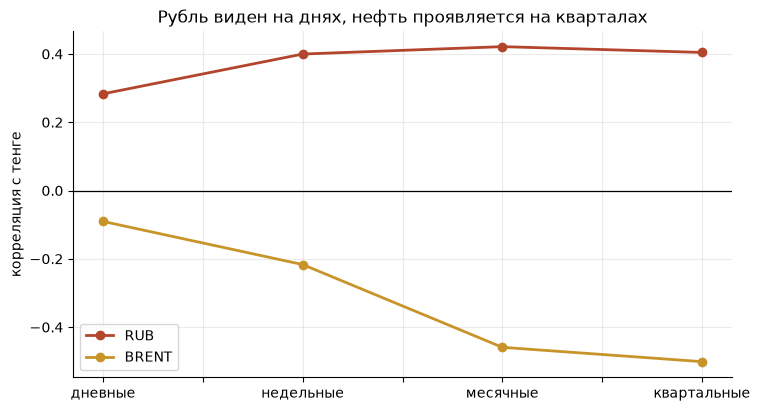

In [11]:
ax = horizons_post[["RUB", "BRENT"]].plot(marker="o", lw=2,
                                          color=["#b3452c", "#c8942a"], figsize=(8.5, 4.5))
ax.axhline(0, color="black", lw=.9)
ax.set_ylabel("корреляция с тенге")
ax.set_title("Рубль виден на днях, нефть проявляется на кварталах")
plt.show()

Вот и ответ на спор. На дневных данных нефть почти не видна (−0,09),
на квартальных она обгоняет рубль (−0,50 против +0,40).

Похоже, обе народные версии верны — просто про разные горизонты.
Но прежде чем на этом остановиться, стоит проверить цифру на прочность.

## 6. А до плавания?

In [12]:
horizons_pre = A.horizon_profile(prices[prices.index < FLOAT], "KZT", peers)
horizons_pre.round(3)

,RUB,BRENT,CNY,EUR,NOK,наблюдений
дневные,0.017,0.004,0.006,0.007,-0.009,2434.0
недельные,0.092,-0.024,0.014,0.018,-0.012,555.0
месячные,0.099,-0.068,0.161,0.075,0.061,128.0
квартальные,0.288,0.001,0.324,0.224,0.028,43.0


Ни нефти, ни рубля. До августа 2015 года тенге не был связан ни с чем:
корреляции колеблются вокруг нуля на всех горизонтах.

Это важный вывод сам по себе. Плавающий курс не «ослабил» связи
и не «отпустил» тенге к рынку — он **создал** эти связи. Пока курс был
решением регулятора, никакой рынок в него не транслировался.

## 7. Проверка на устойчивость

Корреляция Пирсона на месячных и квартальных данных легко утаскивается
несколькими катастрофическими периодами. Смотрим на ту же связь четырьмя
способами: обычный Пирсон, ранговый Спирмен (нечувствителен к величине
выбросов), без периодов с движением нефти больше 40% и без 2020 года.

In [13]:
robust_oil = A.robustness_profile(prices[prices.index >= FLOAT], "KZT", "BRENT")
robust_oil.round(3)

,Пирсон,Спирмен,без движений >40%,без 2020 года,наблюдений
дневные,-0.090,-0.132,-0.103,-0.071,2579.0
недельные,-0.217,-0.284,-0.217,-0.132,577.0
месячные,-0.459,-0.284,-0.262,-0.262,133.0
квартальные,-0.501,-0.256,-0.084,-0.224,44.0


In [14]:
robust_rub = A.robustness_profile(prices[prices.index >= FLOAT], "KZT", "RUB")
robust_rub.round(3)

,Пирсон,Спирмен,без движений >40%,без 2020 года,наблюдений
дневные,0.287,0.323,0.287,0.269,2720.0
недельные,0.400,0.384,0.400,0.372,577.0
месячные,0.421,0.398,0.421,0.360,133.0
квартальные,0.404,0.486,0.508,0.283,44.0


И вот здесь картина меняется.

**Рубль проверку выдерживает**: 0,40 по Пирсону, 0,49 по рангам, 0,51 без
экстремальных кварталов. Все четыре способа дают примерно одно и то же.

**Нефть — нет**: квартальные −0,50 по Пирсону превращаются в −0,26 по рангам
и в −0,08 после удаления кварталов с обвалами. То есть красивая
«квартальная нефтяная связь» держится на нескольких катастрофах — марте 2020
в первую очередь.

Честная формулировка получается такой: связь с нефтью существует,
но она вся в крупных движениях. В спокойные кварталы нефть про тенге
не говорит почти ничего.

Что любопытно, это ровно та же хвостовая логика, которую первый ноутбук
нашёл для рубля на дневных данных: связь включается только в шторм.
Только у рубля шторм измеряется днями, а у нефти — кварталами.

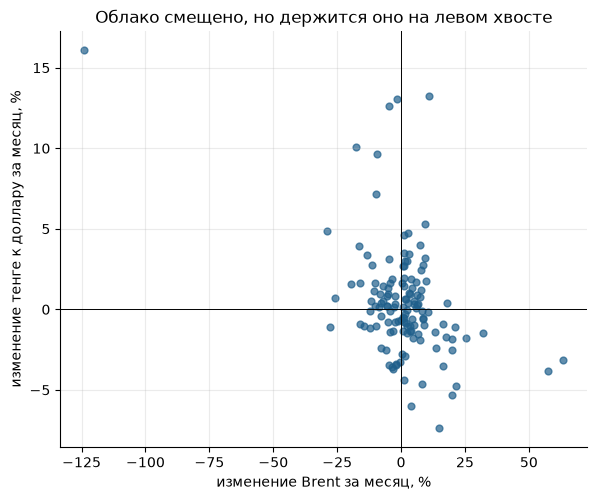

In [15]:
brent_monthly = np.log(
    features.resample_prices(prices[prices.index >= FLOAT][["KZT", "BRENT", "RUB"]], "ME")
).diff().dropna()

fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.scatter(brent_monthly["BRENT"] * 100, brent_monthly["KZT"] * 100, s=24, alpha=.7, color="#1f5f8b")
ax.axhline(0, color="black", lw=.7); ax.axvline(0, color="black", lw=.7)
ax.set_xlabel("изменение Brent за месяц, %")
ax.set_ylabel("изменение тенге к доллару за месяц, %")
ax.set_title("Облако смещено, но держится оно на левом хвосте")
plt.show()

## 8. Сколько объясняют обе версии вместе

In [16]:
post_rets = rets[rets.index >= FLOAT].copy()
post_rets["BRENT_lag1"] = features.lagged(post_rets, "BRENT", 1)
monthly = brent_monthly.rename(columns={"BRENT": "BRENT_lag1"})

for label, frame in (("дневные", post_rets), ("месячные", monthly)):
    for regs in (["BRENT_lag1"], ["RUB"], ["BRENT_lag1", "RUB"]):
        fit = A.explained_variance(frame, "KZT", regs)
        betas = ", ".join(f"{k}={v:+.3f}" for k, v in fit["betas"].items())
        print(f"{label:9s} {' + '.join(regs):20s} R2={fit['r2']:.3f}  n={fit['n']:4d}  {betas}")

дневные   BRENT_lag1           R2=0.025  n=2560  BRENT_lag1=-0.036
дневные   RUB                  R2=0.061  n=2710  RUB=+0.183
дневные   BRENT_lag1 + RUB     R2=0.096  n=2560  BRENT_lag1=-0.032, RUB=+0.158
месячные  BRENT_lag1           R2=0.211  n= 133  BRENT_lag1=-0.098
месячные  RUB                  R2=0.178  n= 133  RUB=+0.253
месячные  BRENT_lag1 + RUB     R2=0.317  n= 133  BRENT_lag1=-0.082, RUB=+0.201


На месячных данных нефть и рубль вместе объясняют 32% движений тенге.
По отдельности — 21% и 18%, то есть они рассказывают во многом разные истории
и хорошо дополняют друг друга. На дневных — 10% на двоих.

## Что получилось

1. **Плавающий курс создал связи, а не ослабил их.** До августа 2015 года
   тенге не коррелировал ни с нефтью, ни с рублём ни на одном горизонте.
2. **Три дня из 5333 дают 47% всего ослабления за двадцать лет.** Это не
   волатильность, это переключения режима: 2009, 2014 и август 2015.
3. **Тенге реагирует на нефть вчерашнего дня** — потому что утренняя сессия
   KASE закрывается раньше, чем лондонский нефтяной рынок.
4. **Спор «рубль или нефть» решается горизонтом — но не поровну.** Связь
   с рублём устойчива при любой проверке. Связь с нефтью на квартальных
   данных выглядит сильнее, но рассыпается на рангах и без экстремальных
   кварталов.
5. **Обе связи хвостовые.** Тенге игнорирует и рубль, и нефть, пока
   движение не станет большим.

Полный разбор с оговорками — в [reports/findings.md](../reports/findings.md).